In [2]:
from sklearn import datasets, neighbors, linear_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline 

digits = datasets.load_digits()
X_digits = digits.data
y_digits = digits.target
y=np.where(y_digits<5,0,1)


/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [0]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_digits, y, test_size=0.2, random_state=0)

In [4]:
from sklearn.linear_model import LogisticRegression
logisticRegr = LogisticRegression()
logisticRegr.fit(x_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [0]:
predictions = logisticRegr.predict(x_test)

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions, target_names=['<5', '>=5']))
acc = logisticRegr.score(x_test,y_test)
print(acc)


              precision    recall  f1-score   support

          <5       0.87      0.91      0.89       157
         >=5       0.93      0.89      0.91       203

    accuracy                           0.90       360
   macro avg       0.90      0.90      0.90       360
weighted avg       0.90      0.90      0.90       360

0.9


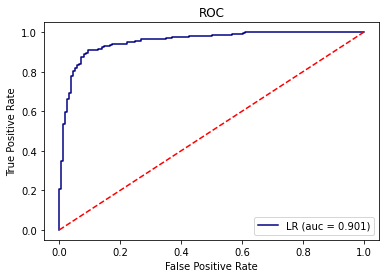

In [7]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

roc_auc = roc_auc_score(y_test, logisticRegr.predict(x_test))
fpr, tpr, thresholds = roc_curve(y_test, logisticRegr.predict_proba(x_test)[:,1])
plt.plot(fpr, tpr, label='LR (auc = %0.3f)' % roc_auc, color='navy')
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

Text(0.5, 1.0, 'Tahmin: 6\n  Fotoğraftaki Rakam: 6\n')

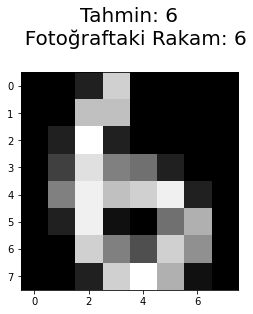

In [14]:
from random import seed
from random import choice
digits = datasets.load_digits()
X_digits = digits.data
y_digits = digits.target
x_trrain, x_teest, y_trrain, y_teest = train_test_split(X_digits, y_digits, test_size=0.2, random_state=0)
logisticc = LogisticRegression()
logisticc.fit(x_trrain, y_trrain)
predictions = logisticRegr.predict(x_teest)

indices = np.arange(len(x_teest))
selection=choice(indices)
tahmin=logisticc.predict(x_teest[selection].reshape(1,-1))
plt.imshow(np.reshape(x_teest[selection], (8,8)), cmap=plt.cm.gray)
plt.title('Tahmin: %i\n  Fotoğraftaki Rakam: %i\n' %( tahmin, y_teest[selection]), fontsize = 20)





